# RAVDESS audio-video w/ iSyncTab_AV

# Sensitivity Ablation

Device: cuda
Feature CSV: C:\Users\ah00069\Downloads\RAVDESS\ravdess_all_sample_stratified_split_with_resnet50_logmel_features.csv
Output dir: C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best
Epochs per setting: 20

Dataset sizes:
Train: 1961
Val: 245
Test: 246

Emotion distribution:
split      test  train  val   All
emotion                          
angry        38    301   37   376
calm         38    301   37   376
disgust      19    153   20   192
fearful      38    301   37   376
happy        37    301   38   376
neutral      19    150   19   188
sad          38    301   37   376
surprised    19    153   20   192
All         246   1961  245  2452

Vocal-channel distribution:
split          test  train  val   All
vocal_channel                        
song             95    810  107  1012
speech          151   1151  138  1440
All             246   1961  245  2452

Run 1/35: metric=variance, k=3
[variance    | k=03] Epoch 01/20 | train_acc=0.2483 | val_acc=0.38

C:\Users\ah00069\AppData\Local\Temp\1\ipykernel_19884\361044996.py:777: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_with_ref = pd.concat(


num_clusters,3,4,5,6,7,8,9
metric,,,,,,,
correlation,0.930894,0.939024,0.934959,0.930894,0.930894,0.926829,0.906504
cosine,0.926829,0.914634,0.918699,0.939024,0.922764,0.943089,0.930894
euclidean,0.926829,0.947154,0.975610,0.930894,0.951220,0.918699,0.939024
kl,0.930894,0.943089,0.914634,0.939024,0.943089,0.926829,0.922764
variance,0.939024,0.930894,0.939024,0.934959,0.930894,0.910569,0.939024



Test balanced accuracy pivot:


num_clusters,3,4,5,6,7,8,9
metric,,,,,,,
correlation,0.920875,0.934122,0.917674,0.917496,0.920964,0.907895,0.881490
cosine,0.917674,0.887980,0.894737,0.934122,0.911006,0.927632,0.917585
euclidean,0.921053,0.937322,0.973595,0.917674,0.950658,0.904427,0.920964
kl,0.917763,0.934122,0.897671,0.933944,0.937322,0.914296,0.907717
variance,0.930832,0.917674,0.927632,0.924253,0.920875,0.894559,0.940612



Test loss pivot:


num_clusters,3,4,5,6,7,8,9
metric,,,,,,,
correlation,0.193545,0.190418,0.223382,0.187634,0.161518,0.228629,0.269229
cosine,0.212425,0.240295,0.222206,0.177112,0.184156,0.192844,0.215399
euclidean,0.239763,0.142700,0.116908,0.202401,0.200857,0.174183,0.190125
kl,0.203772,0.214353,0.237175,0.201194,0.181968,0.187505,0.246477
variance,0.158988,0.194243,0.195394,0.173937,0.173415,0.276437,0.162313



Best summary:


,selection,metric,num_clusters,seed,epochs,best_epoch,best_val_acc,test_acc,test_balanced_acc,test_loss,test_ce,test_fs,elapsed_sec,is_optuna_best_reference
0,best_by_test_acc,euclidean,5,2036,20,17.0,0.946939,0.975610,0.973595,0.116908,0.092802,0.084615,106.453693,NaN
1,best_by_test_balanced_acc,euclidean,5,2036,20,17.0,0.946939,0.975610,0.973595,0.116908,0.092802,0.084615,106.453693,NaN
2,optuna_best_reference,variance,6,optuna_best,optuna_final,NaN,NaN,0.934959,0.924342,0.236756,NaN,NaN,NaN,True



Saved best summary to:
C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_metric_k_sensitivity_best_summary.csv


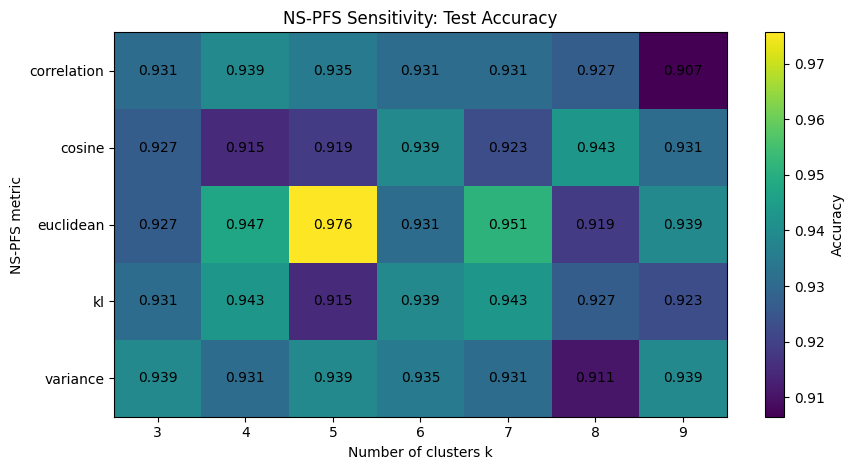

Saved plot: C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_accuracy_heatmap.png


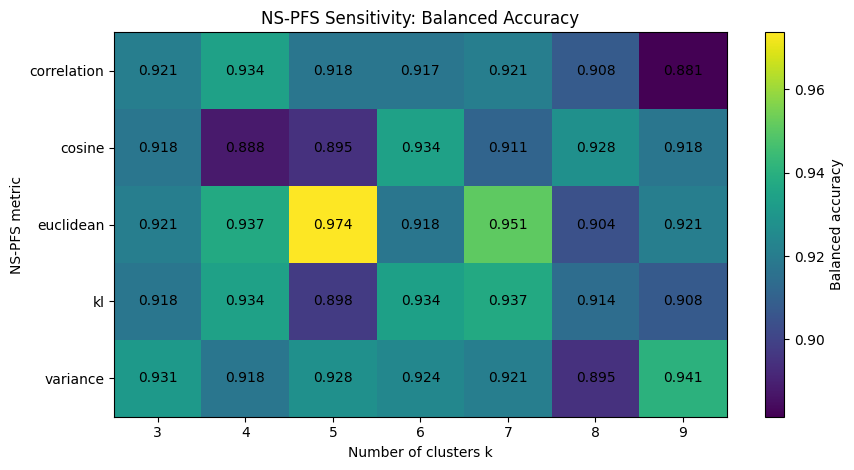

Saved plot: C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_balanced_accuracy_heatmap.png


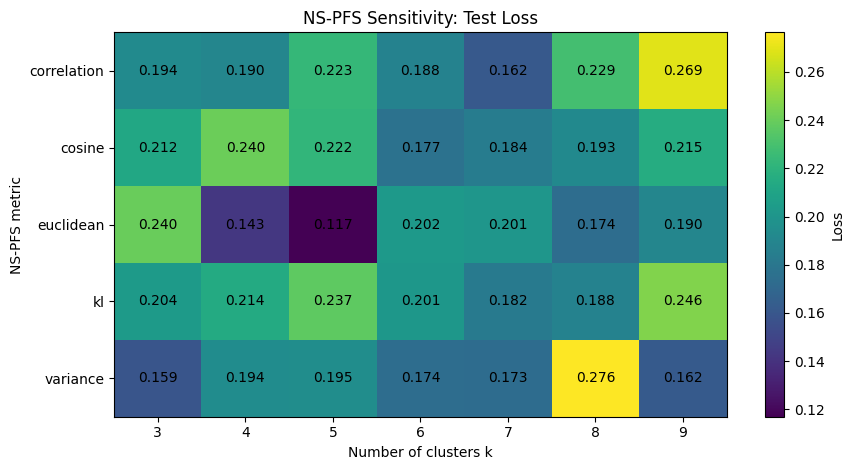

Saved plot: C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_loss_heatmap.png


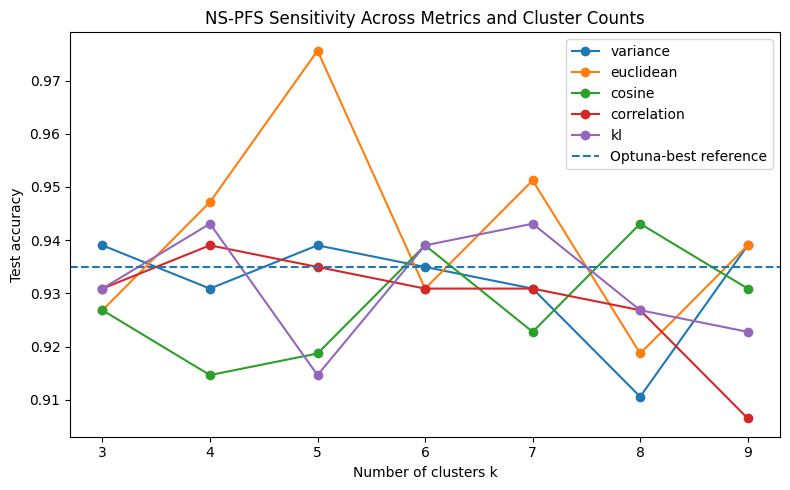

Saved line plot: C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_accuracy_vs_k.png

================ FINAL SENSITIVITY SUMMARY ================
Optuna-best reference:
metric=variance, k=6, acc=0.9350, bal_acc=0.9243

Best fixed-hyperparameter sensitivity result by accuracy:
metric=euclidean, k=5, acc=0.9756, bal_acc=0.9736, loss=0.1169

Best fixed-hyperparameter sensitivity result by balanced accuracy:
metric=euclidean, k=5, acc=0.9756, bal_acc=0.9736, loss=0.1169


In [ ]:
# ======================================================
# iSyncTab-AV NS-PFS Sensitivity Ablation
# Fixed best hyperparameters, no Optuna.
#
# Varies only:
#   - NS-PFS metric
#   - number of clusters k
#
# Retrains each setting from scratch so OMT/Linformer sees the
# corresponding sequence during training.
#
# Also includes the Optuna-best result as reference:
#   accuracy = 0.934959
#   balanced accuracy = 0.924342
# ======================================================

from pathlib import Path
import random
import gc
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from linformer import Linformer


# ======================================================
# 0. Paths
# ======================================================
RAVDESS_ROOT = Path(r"C:\Users\ah00069\Downloads\RAVDESS")

FEATURE_CSV = RAVDESS_ROOT / "ravdess_all_sample_stratified_split_with_resnet50_logmel_features.csv"

OUT_DIR = RAVDESS_ROOT / "nspfs_sensitivity_ablation_fixed_best"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUT_DIR / "nspfs_metric_k_sensitivity_results.csv"
BEST_SUMMARY_CSV = OUT_DIR / "nspfs_metric_k_sensitivity_best_summary.csv"

ACC_PLOT = OUT_DIR / "nspfs_sensitivity_accuracy_heatmap.png"
BAL_ACC_PLOT = OUT_DIR / "nspfs_sensitivity_balanced_accuracy_heatmap.png"
LOSS_PLOT = OUT_DIR / "nspfs_sensitivity_loss_heatmap.png"

assert FEATURE_CSV.exists(), f"Missing feature CSV: {FEATURE_CSV}"


# ======================================================
# 1. Best Optuna hyperparameters
# ======================================================
BEST_PARAMS = {
    "d_model": 256,
    "linformer_heads": 8,
    "linformer_depth": 4,
    "linformer_k": 32,
    "num_clusters": 6,
    "metric": "variance",
    "dropout": 0.1354087338084182,
    "lr": 0.0018775474231961633,
    "weight_decay": 3.277582630232548e-05,
    "batch_size": 32,
    "lambda_fs": 0.28489162372638965,
}

# Your current Optuna-best test result.
OPTUNA_BEST_REFERENCE = {
    "metric": "variance",
    "num_clusters": 6,
    "test_acc": 0.9349593495934959,
    "test_balanced_acc": 0.9243421052631579,
    "test_loss": 0.23675606213510036,
}


# ======================================================
# 2. Global config
# ======================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 8
AUDIO_LEN = 32
VIDEO_LEN = 16
AUDIO_DIM = 64
VIDEO_DIM = 2048

CLASS_NAMES = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

# Sensitivity grid
METRIC_VALUES = ["variance", "euclidean", "cosine", "correlation", "kl"]
CLUSTER_VALUES = [3, 4, 5, 6, 7, 8, 9]

# Training budget for each sensitivity run.
# Increase to 20 if time allows. Start with 10 if you want fast results.
EPOCHS_ABLATION = 20

SEED_BASE = 2026

print("Device:", DEVICE)
print("Feature CSV:", FEATURE_CSV)
print("Output dir:", OUT_DIR)
print("Epochs per setting:", EPOCHS_ABLATION)


# ======================================================
# 3. Reproducibility
# ======================================================
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.use_deterministic_algorithms(True, warn_only=True)


# ======================================================
# 4. Safe feature loading
# ======================================================
def safe_feature_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except Exception:
        return torch.load(path, map_location=map_location, weights_only=False)


# ======================================================
# 5. Dataset
# ======================================================
class RAVDESSFeatureDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio = safe_feature_load(row["audio_feature_path"], map_location="cpu").float()
        video = safe_feature_load(row["video_feature_path"], map_location="cpu").float()
        y = int(row["label"])

        if audio.shape != (AUDIO_LEN, AUDIO_DIM):
            raise ValueError(f"Bad audio shape {audio.shape} at idx={idx}")

        if video.shape != (VIDEO_LEN, VIDEO_DIM):
            raise ValueError(f"Bad video shape {video.shape} at idx={idx}")

        return audio, video, torch.tensor(y, dtype=torch.long)


df_all = pd.read_csv(FEATURE_CSV)
df_all["label"] = df_all["label"].astype(int)

df_train = df_all[df_all["split"] == "train"].copy()
df_val = df_all[df_all["split"] == "val"].copy()
df_test = df_all[df_all["split"] == "test"].copy()

ds_train = RAVDESSFeatureDataset(df_train)
ds_val = RAVDESSFeatureDataset(df_val)
ds_test = RAVDESSFeatureDataset(df_test)
ds_trainval = ConcatDataset([ds_train, ds_val])

print("\nDataset sizes:")
print("Train:", len(ds_train))
print("Val:", len(ds_val))
print("Test:", len(ds_test))

print("\nEmotion distribution:")
print(pd.crosstab(df_all["emotion"], df_all["split"], margins=True))

print("\nVocal-channel distribution:")
print(pd.crosstab(df_all["vocal_channel"], df_all["split"], margins=True))


def make_loaders(batch_size, use_trainval=False):
    pin = DEVICE.type == "cuda"

    train_source = ds_trainval if use_trainval else ds_train

    train_loader = DataLoader(
        train_source,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=pin,
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin,
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin,
    )

    return train_loader, val_loader, test_loader


# ======================================================
# 6. Order-preserving permutation utilities
# ======================================================
def ordered_unique_1d(x):
    seen = set()
    out = []

    for v in x.detach().cpu().tolist():
        v = int(v)
        if v not in seen:
            seen.add(v)
            out.append(v)

    return torch.tensor(out, dtype=torch.long, device=x.device)


def ordered_missing_indices(total_len, perm, device):
    seen = set(int(v) for v in perm.detach().cpu().tolist())
    missing = [i for i in range(total_len) if i not in seen]
    return torch.tensor(missing, dtype=torch.long, device=device)


# ======================================================
# 7. KMeans
# ======================================================
@torch.no_grad()
def kmeans_torch(X_points, k, iters=30, tol=1e-4):
    device = X_points.device
    P, D = X_points.shape

    if P < k:
        k = P

    idx = torch.randperm(P, device=device)[:k]
    C = X_points[idx].clone()

    prev_shift = None

    for _ in range(iters):
        dists = torch.cdist(X_points, C, p=2)
        labels = dists.argmin(dim=1)

        newC = torch.zeros_like(C)

        for ci in range(k):
            mask = labels == ci
            if mask.any():
                newC[ci] = X_points[mask].mean(dim=0)
            else:
                newC[ci] = X_points[torch.randint(0, P, (1,), device=device)]

        shift = (newC - C).abs().mean().item()
        C = newC

        if prev_shift is not None and abs(prev_shift - shift) < tol:
            break

        prev_shift = shift

    return labels, C


# ======================================================
# 8. Metric-aware NS-PFS
# ======================================================
class NSPFS_MetricAware(nn.Module):
    def __init__(self, num_clusters=6, metric="variance", bins=32):
        super().__init__()
        self.k = int(num_clusters)
        self.metric = str(metric).lower()
        self.bins = int(bins)

    @torch.no_grad()
    def _feature_energy(self, X):
        """
        X: [B, L]
        Returns feature/token energy: [L]
        """
        metric = self.metric

        if metric in ("variance", "var"):
            return torch.var(X, dim=0, unbiased=False).abs()

        if metric in ("euclidean", "l2"):
            center = X.mean(dim=0, keepdim=True)
            return torch.sqrt(((X - center) ** 2).sum(dim=0) + 1e-12)

        if metric in ("manhattan", "l1"):
            center = X.median(dim=0, keepdim=True).values
            return (X - center).abs().sum(dim=0)

        if metric in ("cosine", "cos"):
            Xn = F.normalize(X.T.contiguous(), dim=1)
            mean_dir = F.normalize(Xn.mean(dim=0, keepdim=True), dim=1)
            return (1.0 - (Xn @ mean_dir.T).squeeze(1)).abs()

        if metric in ("correlation", "corr", "pearson"):
            Xm = X - X.mean(dim=0, keepdim=True)
            std = Xm.std(dim=0, unbiased=False).clamp_min(1e-12)
            Z = Xm / std
            mean_z = Z.mean(dim=1, keepdim=True)
            corr_like = (Z * mean_z).mean(dim=0)
            return (1.0 - corr_like.abs()).abs()

        if metric in ("kl", "kl_divergence"):
            xmin, xmax = X.min(), X.max()
            L = X.shape[1]

            if float(xmax - xmin) < 1e-12:
                return torch.zeros(L, device=X.device)

            edges = torch.linspace(xmin, xmax, self.bins + 1, device=X.device)
            idx = torch.bucketize(X, edges) - 1
            idx = idx.clamp(0, self.bins - 1)

            counts = torch.zeros((L, self.bins), device=X.device)
            counts.scatter_add_(1, idx.T, torch.ones_like(idx, dtype=torch.float32).T)

            P = counts / counts.sum(dim=1, keepdim=True).clamp_min(1e-12)
            P = P.clamp_min(1e-12)

            entropy = -(P * P.log()).sum(dim=1)
            return entropy

        return torch.var(X, dim=0, unbiased=False).abs()

    @torch.no_grad()
    def forward(self, tab_tokens, img_tokens):
        """
        Naming follows original iSyncTab:
            tab_tokens = audio tokens [B, A, H]
            img_tokens = video tokens [B, V, H]
        """
        device = tab_tokens.device

        B, A, H = tab_tokens.shape
        B2, V, H2 = img_tokens.shape
        assert B == B2

        tab_scalar = tab_tokens.mean(dim=2)
        img_scalar = img_tokens.mean(dim=2)

        lab_tab, cen_tab = kmeans_torch(tab_scalar.T.contiguous(), k=self.k)
        lab_img, cen_img = kmeans_torch(img_scalar.T.contiguous(), k=self.k)

        tab_idx = [
            torch.nonzero(lab_tab == i, as_tuple=False).flatten()
            for i in range(self.k)
        ]

        img_idx = [
            torch.nonzero(lab_img == i, as_tuple=False).flatten()
            for i in range(self.k)
        ]

        tab_energy = self._feature_energy(tab_scalar)
        img_energy = self._feature_energy(img_scalar)

        Psi = torch.full((self.k, self.k), -1e9, device=device)

        for r in range(self.k):
            for c in range(self.k):
                if tab_idx[r].numel() == 0 or img_idx[c].numel() == 0:
                    continue

                e_tab = tab_energy[tab_idx[r]].sum()
                e_img = img_energy[img_idx[c]].sum()

                energy_coherence = 1.0 - torch.abs(e_tab - e_img) / (e_tab + e_img + 1e-8)
                energy_coherence = energy_coherence.clamp(0.0, 1.0)

                ct = cen_tab[r].flatten()
                ci = cen_img[c].flatten()

                sim = F.cosine_similarity(ct.unsqueeze(0), ci.unsqueeze(0), dim=1).squeeze()
                sim = (sim + 1.0) / 2.0

                Psi[r, c] = energy_coherence * sim

        rr, cc = linear_sum_assignment((-Psi).detach().cpu().numpy())

        seq_parts = []

        for r, c in zip(rr, cc):
            ids = tab_idx[r].tolist() + (A + img_idx[c]).tolist()
            if len(ids) > 0:
                seq_parts.append(torch.tensor(ids, dtype=torch.long, device=device))

        if len(seq_parts) > 0:
            seq = torch.cat(seq_parts)
            perm = ordered_unique_1d(seq)
        else:
            perm = torch.empty(0, dtype=torch.long, device=device)

        missing = ordered_missing_indices(A + V, perm, device)

        if missing.numel() > 0:
            perm = torch.cat([perm, missing])

        return perm.long()


# ======================================================
# 9. iSyncTab-AV model
# ======================================================
class iSyncTabAV(nn.Module):
    def __init__(
        self,
        num_classes,
        audio_dim=64,
        video_dim=2048,
        audio_len=32,
        video_len=16,
        d_model=256,
        num_clusters=6,
        metric="variance",
        linformer_depth=4,
        linformer_heads=8,
        linformer_k=32,
        lambda_fs=0.28489162372638965,
        dropout=0.1354087338084182,
    ):
        super().__init__()

        self.lambda_fs = float(lambda_fs)
        self.audio_len = int(audio_len)
        self.video_len = int(video_len)
        self.seq_len_max = self.audio_len + self.video_len

        self.audio_proj = nn.Sequential(
            nn.LayerNorm(audio_dim),
            nn.Linear(audio_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.video_proj = nn.Sequential(
            nn.LayerNorm(video_dim),
            nn.Linear(video_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.audio_pos = nn.Parameter(torch.randn(1, self.audio_len, d_model) * 0.02)
        self.video_pos = nn.Parameter(torch.randn(1, self.video_len, d_model) * 0.02)

        self.nspfs = NSPFS_MetricAware(
            num_clusters=num_clusters,
            metric=metric,
        )

        self.linformer = Linformer(
            dim=d_model,
            seq_len=self.seq_len_max,
            depth=linformer_depth,
            heads=linformer_heads,
            k=linformer_k,
            one_kv_head=True,
            share_kv=True,
        )

        self.cls_head = nn.Linear(d_model, num_classes)
        self.seq_head = nn.Linear(d_model, 1)

    def forward(self, x_audio, x_video, y=None):
        t_tok = self.audio_proj(x_audio) + self.audio_pos
        i_tok = self.video_proj(x_video) + self.video_pos

        B = t_tok.shape[0]

        perm = self.nspfs(t_tok, i_tok)
        tokens = torch.cat([t_tok, i_tok], dim=1)[:, perm, :]

        z = self.linformer(tokens)

        z_cls = z.mean(dim=1)
        logits = self.cls_head(z_cls)

        seq_scores = self.seq_head(z).squeeze(-1)

        ranks = torch.arange(
            perm.numel(),
            device=logits.device,
            dtype=torch.float32,
        )

        beta = (
            ranks / (ranks[-1] if ranks.numel() > 1 else 1.0)
        ).unsqueeze(0).expand(B, -1)

        out = {
            "logits": logits,
            "perm": perm,
            "seq_scores": seq_scores,
            "beta": beta,
        }

        if y is not None:
            ce = F.cross_entropy(logits, y)
            fs = F.mse_loss(seq_scores, beta)

            out["loss"] = ce + self.lambda_fs * fs
            out["loss_ce"] = ce
            out["loss_fs"] = fs

        return out


def build_model(metric, num_clusters):
    return iSyncTabAV(
        num_classes=NUM_CLASSES,
        audio_dim=AUDIO_DIM,
        video_dim=VIDEO_DIM,
        audio_len=AUDIO_LEN,
        video_len=VIDEO_LEN,
        d_model=BEST_PARAMS["d_model"],
        num_clusters=num_clusters,
        metric=metric,
        linformer_depth=BEST_PARAMS["linformer_depth"],
        linformer_heads=BEST_PARAMS["linformer_heads"],
        linformer_k=BEST_PARAMS["linformer_k"],
        lambda_fs=BEST_PARAMS["lambda_fs"],
        dropout=BEST_PARAMS["dropout"],
    ).to(DEVICE)


# ======================================================
# 10. Train/evaluate helpers
# ======================================================
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    losses = []
    ce_losses = []
    fs_losses = []

    all_y = []
    all_pred = []

    for audio, video, y in loader:
        audio = audio.to(DEVICE, non_blocking=True)
        video = video.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            out = model(audio, video, y=y)
            loss = out["loss"]

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        pred = out["logits"].argmax(dim=1)

        losses.append(out["loss"].item())
        ce_losses.append(out["loss_ce"].item())
        fs_losses.append(out["loss_fs"].item())

        all_y.extend(y.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())

    acc = accuracy_score(all_y, all_pred)
    bal_acc = balanced_accuracy_score(all_y, all_pred)

    return {
        "loss": float(np.mean(losses)),
        "ce": float(np.mean(ce_losses)),
        "fs": float(np.mean(fs_losses)),
        "acc": float(acc),
        "balanced_acc": float(bal_acc),
        "y_true": np.array(all_y),
        "y_pred": np.array(all_pred),
    }


def train_one_setting(metric, num_clusters, seed, epochs=20):
    set_seed(seed, deterministic=False)

    train_loader, val_loader, test_loader = make_loaders(
        BEST_PARAMS["batch_size"],
        use_trainval=False,
    )

    model = build_model(metric=metric, num_clusters=num_clusters)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BEST_PARAMS["lr"],
        weight_decay=BEST_PARAMS["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
    )

    best_val_acc = -1.0
    best_state = None
    best_epoch = -1

    epoch_rows = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_m = run_epoch(model, train_loader, optimizer=optimizer)
        val_m = run_epoch(model, val_loader, optimizer=None)

        scheduler.step()

        epoch_rows.append({
            "metric": metric,
            "num_clusters": num_clusters,
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_acc": train_m["acc"],
            "train_balanced_acc": train_m["balanced_acc"],
            "val_loss": val_m["loss"],
            "val_acc": val_m["acc"],
            "val_balanced_acc": val_m["balanced_acc"],
            "lr": scheduler.get_last_lr()[0],
        })

        if val_m["acc"] > best_val_acc:
            best_val_acc = val_m["acc"]
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"[{metric:11s} | k={num_clusters:02d}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_acc={train_m['acc']:.4f} | "
            f"val_acc={val_m['acc']:.4f} | "
            f"val_bal={val_m['balanced_acc']:.4f}"
        )

    # Load best validation state
    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()

    test_m = run_epoch(model, test_loader, optimizer=None)

    elapsed = time.time() - start_time

    result = {
        "metric": metric,
        "num_clusters": num_clusters,
        "seed": seed,
        "epochs": epochs,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_acc": test_m["acc"],
        "test_balanced_acc": test_m["balanced_acc"],
        "test_loss": test_m["loss"],
        "test_ce": test_m["ce"],
        "test_fs": test_m["fs"],
        "elapsed_sec": elapsed,
    }

    history_df = pd.DataFrame(epoch_rows)
    history_path = OUT_DIR / f"history_metric-{metric}_k-{num_clusters}.csv"
    history_df.to_csv(history_path, index=False)

    # Save confusion matrix for each setting
    cm = confusion_matrix(test_m["y_true"], test_m["y_pred"], labels=list(range(NUM_CLASSES)))
    cm_path = OUT_DIR / f"confusion_metric-{metric}_k-{num_clusters}.csv"
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(cm_path)

    return result, model


# ======================================================
# 11. Run sensitivity ablation
# ======================================================
all_results = []

total_runs = len(METRIC_VALUES) * len(CLUSTER_VALUES)
run_id = 0

for metric in METRIC_VALUES:
    for k in CLUSTER_VALUES:
        run_id += 1

        seed = SEED_BASE + run_id

        print("\n" + "=" * 80)
        print(f"Run {run_id}/{total_runs}: metric={metric}, k={k}")
        print("=" * 80)

        result, model = train_one_setting(
            metric=metric,
            num_clusters=k,
            seed=seed,
            epochs=EPOCHS_ABLATION,
        )

        all_results.append(result)

        results_df = pd.DataFrame(all_results)
        results_df.to_csv(RESULTS_CSV, index=False)

        print(
            f"[DONE] metric={metric}, k={k} | "
            f"best_val={result['best_val_acc']:.4f} | "
            f"test_acc={result['test_acc']:.4f} | "
            f"test_bal={result['test_balanced_acc']:.4f}"
        )

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_CSV, index=False)

print("\nSaved full sensitivity results to:")
print(RESULTS_CSV)


# ======================================================
# 12. Add Optuna-best reference row
# ======================================================
reference_row = {
    "metric": OPTUNA_BEST_REFERENCE["metric"],
    "num_clusters": OPTUNA_BEST_REFERENCE["num_clusters"],
    "seed": "optuna_best",
    "epochs": "optuna_final",
    "best_epoch": None,
    "best_val_acc": None,
    "test_acc": OPTUNA_BEST_REFERENCE["test_acc"],
    "test_balanced_acc": OPTUNA_BEST_REFERENCE["test_balanced_acc"],
    "test_loss": OPTUNA_BEST_REFERENCE["test_loss"],
    "test_ce": None,
    "test_fs": None,
    "elapsed_sec": None,
    "is_optuna_best_reference": True,
}

results_with_ref = pd.concat(
    [
        results_df.assign(is_optuna_best_reference=False),
        pd.DataFrame([reference_row]),
    ],
    ignore_index=True,
)

results_with_ref_csv = OUT_DIR / "nspfs_metric_k_sensitivity_results_with_optuna_reference.csv"
results_with_ref.to_csv(results_with_ref_csv, index=False)

print("\nSaved results with Optuna reference to:")
print(results_with_ref_csv)


# ======================================================
# 13. Pivot tables
# ======================================================
acc_pivot = results_df.pivot(index="metric", columns="num_clusters", values="test_acc")
bal_pivot = results_df.pivot(index="metric", columns="num_clusters", values="test_balanced_acc")
loss_pivot = results_df.pivot(index="metric", columns="num_clusters", values="test_loss")

print("\nTest accuracy pivot:")
display(acc_pivot)

print("\nTest balanced accuracy pivot:")
display(bal_pivot)

print("\nTest loss pivot:")
display(loss_pivot)


# ======================================================
# 14. Best sensitivity setting summary
# ======================================================
best_acc_row = results_df.sort_values("test_acc", ascending=False).iloc[0]
best_bal_row = results_df.sort_values("test_balanced_acc", ascending=False).iloc[0]

summary_rows = [
    {
        "selection": "best_by_test_acc",
        **best_acc_row.to_dict(),
    },
    {
        "selection": "best_by_test_balanced_acc",
        **best_bal_row.to_dict(),
    },
    {
        "selection": "optuna_best_reference",
        **reference_row,
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(BEST_SUMMARY_CSV, index=False)

print("\nBest summary:")
display(summary_df)

print("\nSaved best summary to:")
print(BEST_SUMMARY_CSV)


# ======================================================
# 15. Plot helper
# ======================================================
def plot_heatmap(pivot_df, title, value_label, out_path):
    fig, ax = plt.subplots(figsize=(9, 4.8))

    data = pivot_df.values.astype(float)

    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))

    ax.set_xticklabels([str(c) for c in pivot_df.columns])
    ax.set_yticklabels([str(i) for i in pivot_df.index])

    ax.set_xlabel("Number of clusters k")
    ax.set_ylabel("NS-PFS metric")
    ax.set_title(title)

    # Annotate values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(
                j,
                i,
                f"{data[i, j]:.3f}",
                ha="center",
                va="center",
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_label)

    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", out_path)


plot_heatmap(
    acc_pivot,
    title="NS-PFS Sensitivity: Test Accuracy",
    value_label="Accuracy",
    out_path=ACC_PLOT,
)

plot_heatmap(
    bal_pivot,
    title="NS-PFS Sensitivity: Balanced Accuracy",
    value_label="Balanced accuracy",
    out_path=BAL_ACC_PLOT,
)

plot_heatmap(
    loss_pivot,
    title="NS-PFS Sensitivity: Test Loss",
    value_label="Loss",
    out_path=LOSS_PLOT,
)


# ======================================================
# 16. Optional: line plot over k for each metric
# ======================================================
LINE_PLOT = OUT_DIR / "nspfs_sensitivity_accuracy_vs_k.png"

fig, ax = plt.subplots(figsize=(8, 5))

for metric in METRIC_VALUES:
    sub = results_df[results_df["metric"] == metric].sort_values("num_clusters")
    ax.plot(
        sub["num_clusters"].values,
        sub["test_acc"].values,
        marker="o",
        label=metric,
    )

# Add Optuna best reference line
ax.axhline(
    OPTUNA_BEST_REFERENCE["test_acc"],
    linestyle="--",
    label="Optuna-best reference",
)

ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Test accuracy")
ax.set_title("NS-PFS Sensitivity Across Metrics and Cluster Counts")
ax.legend()
fig.tight_layout()
fig.savefig(LINE_PLOT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved line plot:", LINE_PLOT)


# ======================================================
# 17. Print concise final numbers
# ======================================================
print("\n================ FINAL SENSITIVITY SUMMARY ================")
print("Optuna-best reference:")
print(
    f"metric={OPTUNA_BEST_REFERENCE['metric']}, "
    f"k={OPTUNA_BEST_REFERENCE['num_clusters']}, "
    f"acc={OPTUNA_BEST_REFERENCE['test_acc']:.4f}, "
    f"bal_acc={OPTUNA_BEST_REFERENCE['test_balanced_acc']:.4f}"
)

print("\nBest fixed-hyperparameter sensitivity result by accuracy:")
print(
    f"metric={best_acc_row['metric']}, "
    f"k={int(best_acc_row['num_clusters'])}, "
    f"acc={best_acc_row['test_acc']:.4f}, "
    f"bal_acc={best_acc_row['test_balanced_acc']:.4f}, "
    f"loss={best_acc_row['test_loss']:.4f}"
)

print("\nBest fixed-hyperparameter sensitivity result by balanced accuracy:")
print(
    f"metric={best_bal_row['metric']}, "
    f"k={int(best_bal_row['num_clusters'])}, "
    f"acc={best_bal_row['test_acc']:.4f}, "
    f"bal_acc={best_bal_row['test_balanced_acc']:.4f}, "
    f"loss={best_bal_row['test_loss']:.4f}"
)


================ FIXED REFERENCE CONFIGURATION ================
d_model: 256
linformer_heads: 8
linformer_depth: 4
linformer_k: 32
num_clusters: 6
metric: variance
dropout: 0.1354087338084182
lr: 0.0018775474231961633
weight_decay: 3.277582630232548e-05
batch_size: 32
lambda_fs: 0.28489162372638965

================ FIXED REFERENCE RESULT ================
Test accuracy:          0.9350
Test balanced accuracy: 0.9243
Test loss:              0.2368

================ BEST SENSITIVITY RESULT BY ACCURACY ================
Metric:                 euclidean
Number of clusters k:   5
Test accuracy:          0.9756
Test balanced accuracy: 0.9736
Test loss:              0.1169

================ BEST SENSITIVITY RESULT BY BALANCED ACCURACY ================
Metric:                 euclidean
Number of clusters k:   5
Test accuracy:          0.9756
Test balanced accuracy: 0.9736
Test loss:              0.1169


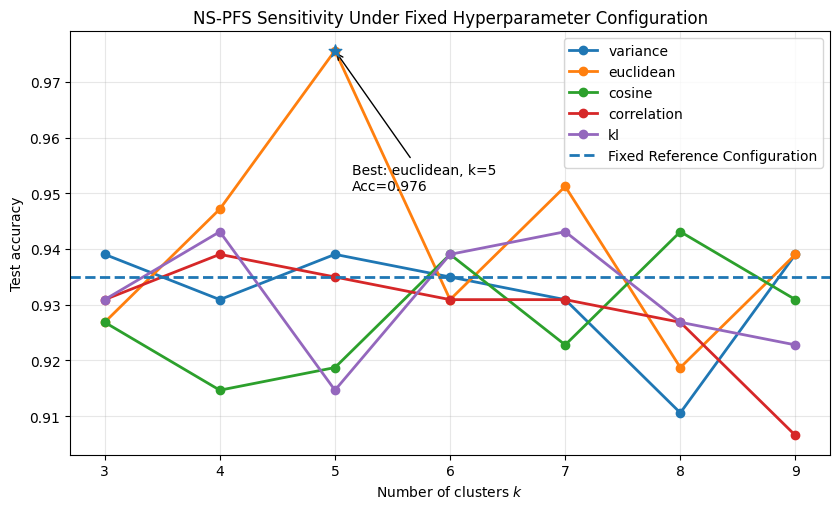


Saved plot:
C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_single_line_plot.png
C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_single_line_plot.pdf


In [ ]:
# ======================================================
# Plot-only NS-PFS Sensitivity Figure
# No retraining. No Optuna.
#
# Reads:
#   nspfs_metric_k_sensitivity_results.csv
#
# Produces:
#   Single line plot: accuracy vs k for each metric
#   Reference horizontal line: Fixed Reference Configuration
# ======================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# Paths
# ======================================================
RAVDESS_ROOT = Path(r"C:\Users\ah00069\Downloads\RAVDESS")
OUT_DIR = RAVDESS_ROOT / "nspfs_sensitivity_ablation_fixed_best"

RESULTS_CSV = OUT_DIR / "nspfs_metric_k_sensitivity_results.csv"

LINE_PLOT = OUT_DIR / "nspfs_sensitivity_single_line_plot.png"
LINE_PLOT_PDF = OUT_DIR / "nspfs_sensitivity_single_line_plot.pdf"

assert RESULTS_CSV.exists(), f"Missing results CSV: {RESULTS_CSV}"

# ======================================================
# Fixed reference configuration from 150-trial Optuna run
# ======================================================
FIXED_REFERENCE_CONFIG = {
    "d_model": 256,
    "linformer_heads": 8,
    "linformer_depth": 4,
    "linformer_k": 32,
    "num_clusters": 6,
    "metric": "variance",
    "dropout": 0.1354087338084182,
    "lr": 0.0018775474231961633,
    "weight_decay": 3.277582630232548e-05,
    "batch_size": 32,
    "lambda_fs": 0.28489162372638965,
}

FIXED_REFERENCE_RESULT = {
    "test_acc": 0.9349593495934959,
    "test_balanced_acc": 0.9243421052631579,
    "test_loss": 0.23675606213510036,
}

# ======================================================
# Load sensitivity results
# ======================================================
df = pd.read_csv(RESULTS_CSV)

required_cols = ["metric", "num_clusters", "test_acc", "test_balanced_acc", "test_loss"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column in results CSV: {col}")

df["num_clusters"] = df["num_clusters"].astype(int)

# ======================================================
# Best sensitivity result
# ======================================================
best_acc_row = df.sort_values("test_acc", ascending=False).iloc[0]
best_bal_row = df.sort_values("test_balanced_acc", ascending=False).iloc[0]

print("\n================ FIXED REFERENCE CONFIGURATION ================")
for k, v in FIXED_REFERENCE_CONFIG.items():
    print(f"{k}: {v}")

print("\n================ FIXED REFERENCE RESULT ================")
print(f"Test accuracy:          {FIXED_REFERENCE_RESULT['test_acc']:.4f}")
print(f"Test balanced accuracy: {FIXED_REFERENCE_RESULT['test_balanced_acc']:.4f}")
print(f"Test loss:              {FIXED_REFERENCE_RESULT['test_loss']:.4f}")

print("\n================ BEST SENSITIVITY RESULT BY ACCURACY ================")
print(f"Metric:                 {best_acc_row['metric']}")
print(f"Number of clusters k:   {int(best_acc_row['num_clusters'])}")
print(f"Test accuracy:          {best_acc_row['test_acc']:.4f}")
print(f"Test balanced accuracy: {best_acc_row['test_balanced_acc']:.4f}")
print(f"Test loss:              {best_acc_row['test_loss']:.4f}")

print("\n================ BEST SENSITIVITY RESULT BY BALANCED ACCURACY ================")
print(f"Metric:                 {best_bal_row['metric']}")
print(f"Number of clusters k:   {int(best_bal_row['num_clusters'])}")
print(f"Test accuracy:          {best_bal_row['test_acc']:.4f}")
print(f"Test balanced accuracy: {best_bal_row['test_balanced_acc']:.4f}")
print(f"Test loss:              {best_bal_row['test_loss']:.4f}")

# ======================================================
# Single line plot
# ======================================================
metric_order = ["variance", "euclidean", "cosine", "correlation", "kl"]
available_metrics = [m for m in metric_order if m in set(df["metric"])]

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for metric in available_metrics:
    sub = df[df["metric"] == metric].sort_values("num_clusters")
    ax.plot(
        sub["num_clusters"].values,
        sub["test_acc"].values,
        marker="o",
        linewidth=2,
        label=metric,
    )

# Fixed reference horizontal line
ax.axhline(
    FIXED_REFERENCE_RESULT["test_acc"],
    linestyle="--",
    linewidth=2,
    label="Fixed Reference Configuration",
)

# Mark best sensitivity point
ax.scatter(
    [best_acc_row["num_clusters"]],
    [best_acc_row["test_acc"]],
    s=90,
    marker="*",
    zorder=5,
)

ax.annotate(
    f"Best: {best_acc_row['metric']}, k={int(best_acc_row['num_clusters'])}\nAcc={best_acc_row['test_acc']:.3f}",
    xy=(best_acc_row["num_clusters"], best_acc_row["test_acc"]),
    xytext=(best_acc_row["num_clusters"] + 0.15, best_acc_row["test_acc"] - 0.025),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10,
)

ax.set_xlabel("Number of clusters $k$")
ax.set_ylabel("Test accuracy")
ax.set_title("NS-PFS Sensitivity Under Fixed Hyperparameter Configuration")

ax.set_xticks(sorted(df["num_clusters"].unique()))
ax.grid(True, alpha=0.3)
ax.legend(loc="best", frameon=True)

fig.tight_layout()
fig.savefig(LINE_PLOT, dpi=300, bbox_inches="tight")
fig.savefig(LINE_PLOT_PDF, bbox_inches="tight")

plt.show()

print("\nSaved plot:")
print(LINE_PLOT)
print(LINE_PLOT_PDF)


FIXED REFERENCE CONFIGURATION
metric: variance
num_clusters: 6
d_model: 256
linformer_heads: 8
linformer_depth: 4
linformer_k: 32
dropout: 0.135409
lr: 0.00187755
weight_decay: 3.27758e-05
batch_size: 32
lambda_fs: 0.284892
test_acc: 0.934959
test_balanced_acc: 0.924342
test_loss: 0.236756

BEST SENSITIVITY CONFIGURATION BY TEST ACCURACY
metric: euclidean
num_clusters: 5
d_model: 256
linformer_heads: 8
linformer_depth: 4
linformer_k: 32
dropout: 0.135409
lr: 0.00187755
weight_decay: 3.27758e-05
batch_size: 32
lambda_fs: 0.284892
test_acc: 0.97561
test_balanced_acc: 0.973595
test_loss: 0.116908

BEST SENSITIVITY CONFIGURATION BY BALANCED ACCURACY
metric: euclidean
num_clusters: 5
d_model: 256
linformer_heads: 8
linformer_depth: 4
linformer_k: 32
dropout: 0.135409
lr: 0.00187755
weight_decay: 3.27758e-05
batch_size: 32
lambda_fs: 0.284892
test_acc: 0.97561
test_balanced_acc: 0.973595
test_loss: 0.116908


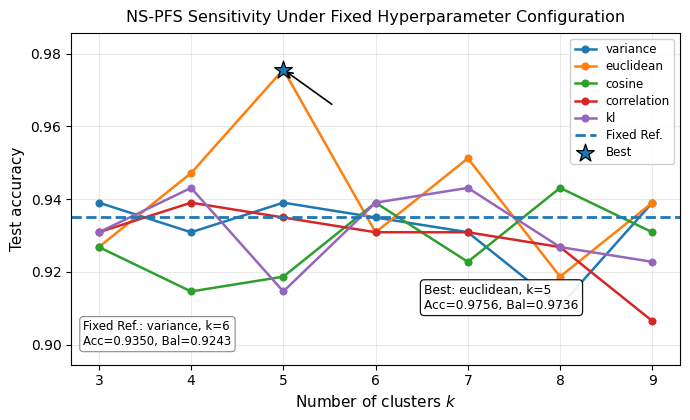


Saved plot:
C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_single_line_plot_compact.png
C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_single_line_plot_compact.pdf

Saved summary CSV:
C:\Users\ah00069\Downloads\RAVDESS\nspfs_sensitivity_ablation_fixed_best\nspfs_sensitivity_plot_summary.csv


In [ ]:
# ======================================================
# Compact Plot-only NS-PFS Sensitivity Figure
# Legend inside, ECCV rebuttal-friendly.
# No retraining. No Optuna.
# ======================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# Paths
# ======================================================
RAVDESS_ROOT = Path(r"C:\Users\ah00069\Downloads\RAVDESS")
OUT_DIR = RAVDESS_ROOT / "nspfs_sensitivity_ablation_fixed_best"

RESULTS_CSV = OUT_DIR / "nspfs_metric_k_sensitivity_results.csv"

LINE_PLOT_PNG = OUT_DIR / "nspfs_sensitivity_single_line_plot_compact.png"
LINE_PLOT_PDF = OUT_DIR / "nspfs_sensitivity_single_line_plot_compact.pdf"

assert RESULTS_CSV.exists(), f"Missing results CSV: {RESULTS_CSV}"

# ======================================================
# Fixed reference configuration from 150-trial run
# ======================================================
FIXED_REFERENCE_CONFIG = {
    "metric": "variance",
    "num_clusters": 6,
    "d_model": 256,
    "linformer_heads": 8,
    "linformer_depth": 4,
    "linformer_k": 32,
    "dropout": 0.1354087338084182,
    "lr": 0.0018775474231961633,
    "weight_decay": 3.277582630232548e-05,
    "batch_size": 32,
    "lambda_fs": 0.28489162372638965,
}

FIXED_REFERENCE_RESULT = {
    "test_acc": 0.9349593495934959,
    "test_balanced_acc": 0.9243421052631579,
    "test_loss": 0.23675606213510036,
}

# ======================================================
# Load sensitivity results
# ======================================================
df = pd.read_csv(RESULTS_CSV)

required_cols = ["metric", "num_clusters", "test_acc", "test_balanced_acc", "test_loss"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column in results CSV: {col}")

df["num_clusters"] = df["num_clusters"].astype(int)

# ======================================================
# Best sensitivity result
# ======================================================
best_acc_row = df.sort_values("test_acc", ascending=False).iloc[0]
best_bal_row = df.sort_values("test_balanced_acc", ascending=False).iloc[0]

# ======================================================
# Print configurations
# ======================================================
def print_config_block(title, config_dict):
    print("\n" + "=" * 76)
    print(title)
    print("=" * 76)
    for k, v in config_dict.items():
        if isinstance(v, float):
            print(f"{k}: {v:.6g}")
        else:
            print(f"{k}: {v}")

FIXED_REFERENCE_FULL_CONFIG = {
    **FIXED_REFERENCE_CONFIG,
    "test_acc": FIXED_REFERENCE_RESULT["test_acc"],
    "test_balanced_acc": FIXED_REFERENCE_RESULT["test_balanced_acc"],
    "test_loss": FIXED_REFERENCE_RESULT["test_loss"],
}

BEST_SENSITIVITY_CONFIG_ACC = {
    "metric": best_acc_row["metric"],
    "num_clusters": int(best_acc_row["num_clusters"]),
    "d_model": FIXED_REFERENCE_CONFIG["d_model"],
    "linformer_heads": FIXED_REFERENCE_CONFIG["linformer_heads"],
    "linformer_depth": FIXED_REFERENCE_CONFIG["linformer_depth"],
    "linformer_k": FIXED_REFERENCE_CONFIG["linformer_k"],
    "dropout": FIXED_REFERENCE_CONFIG["dropout"],
    "lr": FIXED_REFERENCE_CONFIG["lr"],
    "weight_decay": FIXED_REFERENCE_CONFIG["weight_decay"],
    "batch_size": FIXED_REFERENCE_CONFIG["batch_size"],
    "lambda_fs": FIXED_REFERENCE_CONFIG["lambda_fs"],
    "test_acc": float(best_acc_row["test_acc"]),
    "test_balanced_acc": float(best_acc_row["test_balanced_acc"]),
    "test_loss": float(best_acc_row["test_loss"]),
}

BEST_SENSITIVITY_CONFIG_BAL = {
    "metric": best_bal_row["metric"],
    "num_clusters": int(best_bal_row["num_clusters"]),
    "d_model": FIXED_REFERENCE_CONFIG["d_model"],
    "linformer_heads": FIXED_REFERENCE_CONFIG["linformer_heads"],
    "linformer_depth": FIXED_REFERENCE_CONFIG["linformer_depth"],
    "linformer_k": FIXED_REFERENCE_CONFIG["linformer_k"],
    "dropout": FIXED_REFERENCE_CONFIG["dropout"],
    "lr": FIXED_REFERENCE_CONFIG["lr"],
    "weight_decay": FIXED_REFERENCE_CONFIG["weight_decay"],
    "batch_size": FIXED_REFERENCE_CONFIG["batch_size"],
    "lambda_fs": FIXED_REFERENCE_CONFIG["lambda_fs"],
    "test_acc": float(best_bal_row["test_acc"]),
    "test_balanced_acc": float(best_bal_row["test_balanced_acc"]),
    "test_loss": float(best_bal_row["test_loss"]),
}

print_config_block("FIXED REFERENCE CONFIGURATION", FIXED_REFERENCE_FULL_CONFIG)
print_config_block("BEST SENSITIVITY CONFIGURATION BY TEST ACCURACY", BEST_SENSITIVITY_CONFIG_ACC)
print_config_block("BEST SENSITIVITY CONFIGURATION BY BALANCED ACCURACY", BEST_SENSITIVITY_CONFIG_BAL)

# ======================================================
# Compact single line plot
# ======================================================
metric_order = ["variance", "euclidean", "cosine", "correlation", "kl"]
available_metrics = [m for m in metric_order if m in set(df["metric"])]

fig, ax = plt.subplots(figsize=(7.0, 4.3))

for metric in available_metrics:
    sub = df[df["metric"] == metric].sort_values("num_clusters")
    ax.plot(
        sub["num_clusters"].values,
        sub["test_acc"].values,
        marker="o",
        linewidth=1.8,
        markersize=4.8,
        label=metric,
    )

# Fixed reference horizontal line
ax.axhline(
    FIXED_REFERENCE_RESULT["test_acc"],
    linestyle="--",
    linewidth=2.0,
    label="Fixed Ref.",
)

# Best point marker
best_x = int(best_acc_row["num_clusters"])
best_y = float(best_acc_row["test_acc"])

ax.scatter(
    [best_x],
    [best_y],
    s=180,
    marker="*",
    edgecolor="black",
    linewidth=0.9,
    zorder=10,
    label="Best",
)

# Small arrow from text box to best point
ax.annotate(
    "",
    xy=(best_x, best_y),
    xytext=(best_x + 0.55, best_y - 0.010),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2,
        color="black",
    ),
)

# Best text box, compact and inside
best_text = (
    f"Best: {best_acc_row['metric']}, k={best_x}\n"
    f"Acc={best_y:.4f}, Bal={float(best_acc_row['test_balanced_acc']):.4f}"
)

ax.text(
    0.58,
    0.16,
    best_text,
    transform=ax.transAxes,
    fontsize=8.8,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.32",
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        alpha=0.92,
    ),
)

# Reference text box, compact and inside
ref_text = (
    f"Fixed Ref.: {FIXED_REFERENCE_CONFIG['metric']}, k={FIXED_REFERENCE_CONFIG['num_clusters']}\n"
    f"Acc={FIXED_REFERENCE_RESULT['test_acc']:.4f}, "
    f"Bal={FIXED_REFERENCE_RESULT['test_balanced_acc']:.4f}"
)

ax.text(
    0.02,
    0.05,
    ref_text,
    transform=ax.transAxes,
    fontsize=8.5,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="gray",
        linewidth=0.8,
        alpha=0.92,
    ),
)

# Axes formatting
ax.set_xlabel("Number of clusters $k$", fontsize=11)
ax.set_ylabel("Test accuracy", fontsize=11)
ax.set_title(
    "NS-PFS Sensitivity Under Fixed Hyperparameter Configuration",
    fontsize=11.5,
    pad=8,
)

ax.set_xticks(sorted(df["num_clusters"].unique()))

y_min = min(df["test_acc"].min(), FIXED_REFERENCE_RESULT["test_acc"]) - 0.012
y_max = max(df["test_acc"].max(), FIXED_REFERENCE_RESULT["test_acc"]) + 0.010
ax.set_ylim(y_min, y_max)

ax.grid(True, alpha=0.28)

# Legend inside, compact
ax.legend(
    loc="upper right",
    fontsize=8.6,
    frameon=True,
    framealpha=0.92,
    borderpad=0.35,
    labelspacing=0.35,
    handlelength=1.8,
)

fig.tight_layout()
fig.savefig(LINE_PLOT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(LINE_PLOT_PDF, bbox_inches="tight")

plt.show()

print("\nSaved plot:")
print(LINE_PLOT_PNG)
print(LINE_PLOT_PDF)

# ======================================================
# Save compact summary CSV
# ======================================================
SUMMARY_CSV = OUT_DIR / "nspfs_sensitivity_plot_summary.csv"

summary_df = pd.DataFrame([
    {
        "selection": "fixed_reference_configuration",
        **FIXED_REFERENCE_FULL_CONFIG,
    },
    {
        "selection": "best_sensitivity_by_test_accuracy",
        **BEST_SENSITIVITY_CONFIG_ACC,
    },
    {
        "selection": "best_sensitivity_by_balanced_accuracy",
        **BEST_SENSITIVITY_CONFIG_BAL,
    },
])

summary_df.to_csv(SUMMARY_CSV, index=False)

print("\nSaved summary CSV:")
print(SUMMARY_CSV)